<a href="https://colab.research.google.com/github/ThiruvarankanM/RealWaste-CNN-Classfication/blob/main/EN3150_A03_RealWaste_CNN_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN for RealWaste Image Classification
**EN3150 Assignment 03**  
Dataset: RealWaste (UCI ML Repository)  
Total Images: 4,752 | Classes: 9

---

## Setup: Download RealWaste Dataset

Download and extract RealWaste dataset from UCI ML Repository

In [1]:
import os
import urllib.request
import zipfile

# Dataset configuration
url = "https://archive.ics.uci.edu/static/public/908/realwaste.zip"
download_path = "/content/realwaste.zip"
data_dir = "/content/realwaste-main/RealWaste"

# Download and extract if not exists
if not os.path.exists(data_dir):
    print("Downloading RealWaste dataset...")
    urllib.request.urlretrieve(url, download_path)

    print("Extracting dataset...")
    with zipfile.ZipFile(download_path, 'r') as zip_ref:
        zip_ref.extractall("/content")

    os.remove(download_path)
    print("✓ Dataset ready")
else:
    print("✓ Dataset already exists")

# Verify dataset
categories = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print(f"✓ Found {len(categories)} categories: {categories}")

Extracting dataset...
✓ Dataset ready
✓ Found 9 categories: ['Textile Trash', 'Miscellaneous Trash', 'Vegetation', 'Food Organics', 'Cardboard', 'Metal', 'Paper', 'Glass', 'Plastic']


## 1. Import Basic Libraries

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [3]:
import numpy as np
import pandas as pd
from PIL import Image

# Load dataset classes
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
num_classes = len(classes)

print(f"Classes ({num_classes}): {classes}")

Classes (9): ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


In [4]:
# Count images per class
class_counts = {}
for cls in classes:
    count = len([f for f in os.listdir(os.path.join(data_dir, cls)) if f.endswith('.jpg')])
    class_counts[cls] = count

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df['%'] = (df['Count'] / df['Count'].sum() * 100).round(1)
print(df.to_string(index=False))
print(f"\nTotal: {df['Count'].sum()}")

              Class  Count    %
          Cardboard    461  9.7
      Food Organics    411  8.6
              Glass    420  8.8
              Metal    790 16.6
Miscellaneous Trash    495 10.4
              Paper    500 10.5
            Plastic    921 19.4
      Textile Trash    318  6.7
         Vegetation    436  9.2

Total: 4752


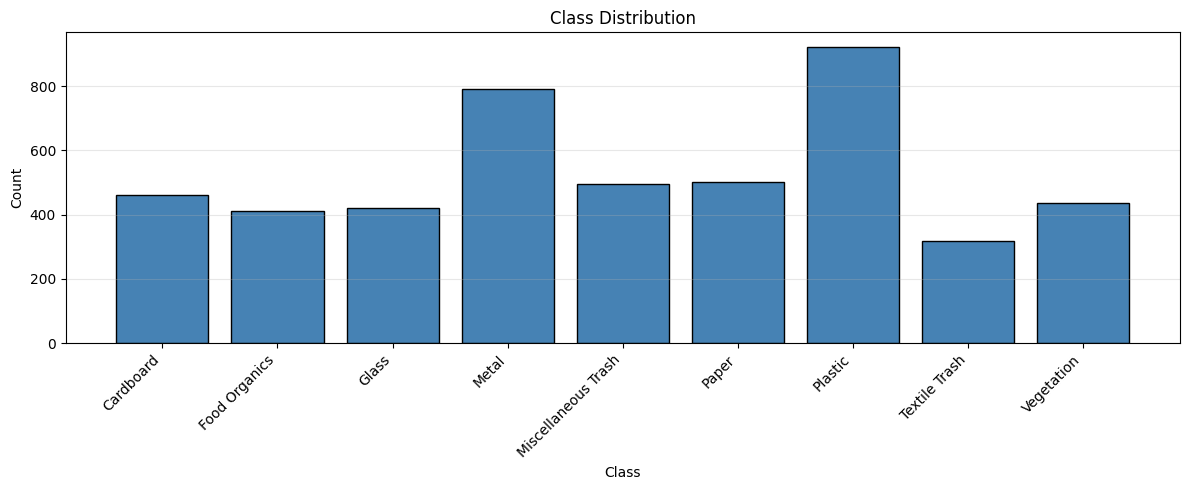

In [5]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distribution
plt.figure(figsize=(12, 5))
plt.bar(df['Class'], df['Count'], color='steelblue', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

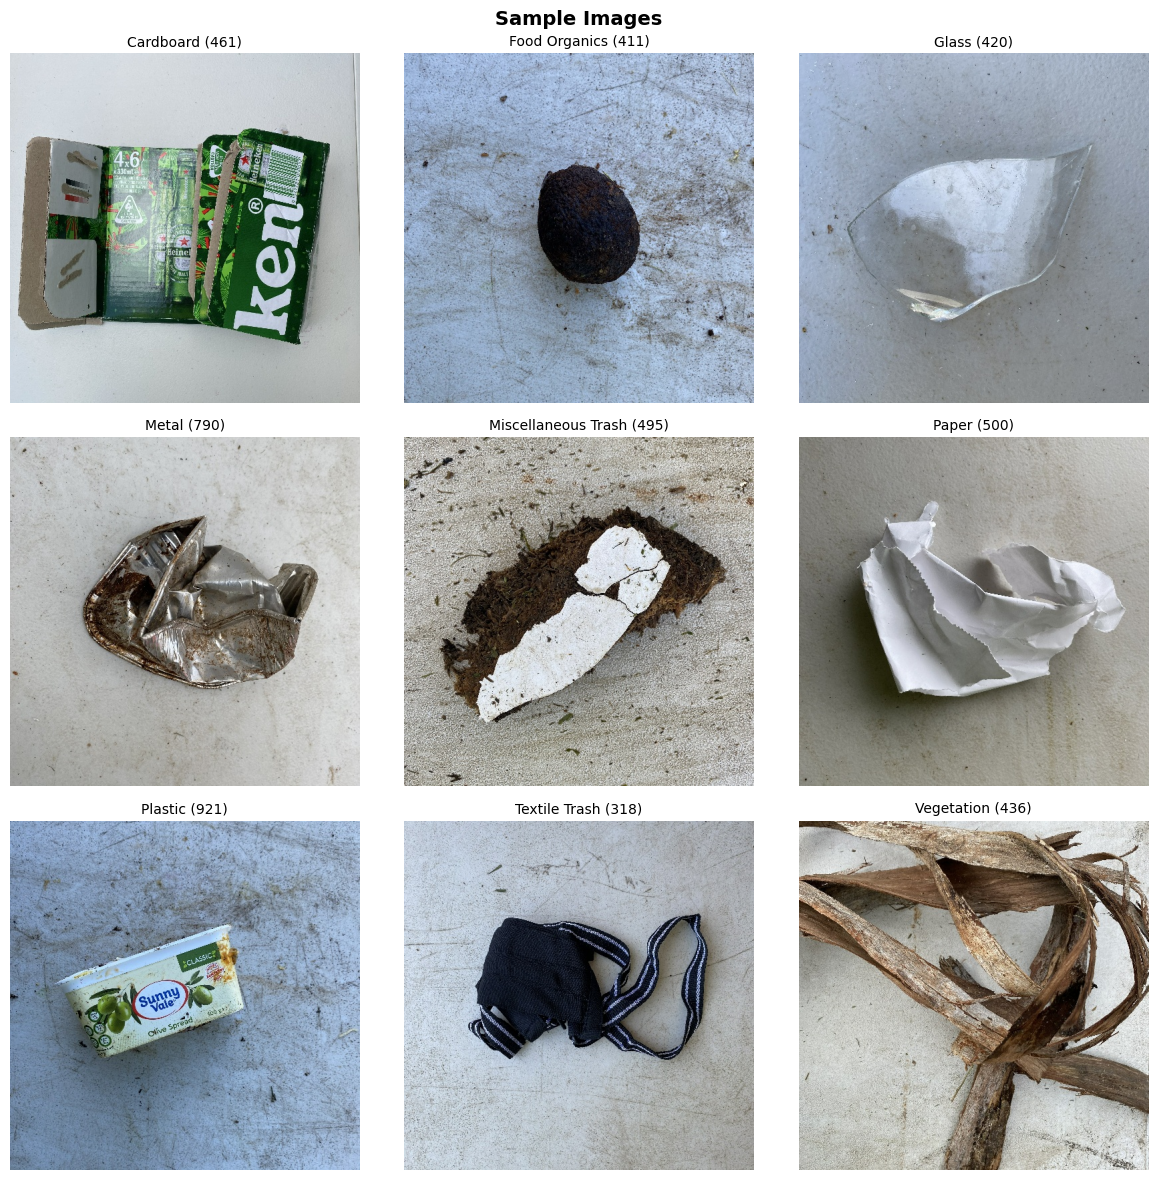

In [6]:
# Sample images
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for idx, cls in enumerate(classes):
    img_file = os.listdir(os.path.join(data_dir, cls))[0]
    img = Image.open(os.path.join(data_dir, cls, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(f'{cls} ({class_counts[cls]})', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Setup TensorFlow and Data Augmentation

In [7]:
# Import TensorFlow and setup GPU
import gc
import tensorflow as tf

# GPU memory optimization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)
else:
    print("✓ Running on CPU")

print("✓ Using float32 for numerical stability")

✓ GPU memory growth enabled
✓ Using float32 for numerical stability


In [8]:
# Clear memory helper
def clear_memory():
    tf.keras.backend.clear_session()
    gc.collect()

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f"Image size: {IMG_SIZE}, Batch size: {BATCH_SIZE}")

Image size: (224, 224), Batch size: 32


## 4. Train/Val/Test Split (70-15-15)

In [10]:
# Import required libraries for splitting
import shutil
from sklearn.model_selection import train_test_split

# Create train/val/test directories
split_dir = 'data_split'
os.makedirs(split_dir, exist_ok=True)

for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, split, cls), exist_ok=True)

# Split 70-15-15
for cls in classes:
    class_path = os.path.join(data_dir, cls)
    files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]

    # Split: 70% train, 30% temp (which will be split into 15% val + 15% test)
    X_train, X_temp = train_test_split(files, test_size=0.30, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.50, random_state=42)

    # Copy training files
    for f in X_train:
        dst = os.path.join(split_dir, 'train', cls, f)
        if not os.path.exists(dst):
            shutil.copy2(os.path.join(class_path, f), dst)

    # Copy validation files
    for f in X_val:
        dst = os.path.join(split_dir, 'val', cls, f)
        if not os.path.exists(dst):
            shutil.copy2(os.path.join(class_path, f), dst)

    # Copy test files
    for f in X_test:
        dst = os.path.join(split_dir, 'test', cls, f)
        if not os.path.exists(dst):
            shutil.copy2(os.path.join(class_path, f), dst)

# Count samples in each split
train_count = sum([len(os.listdir(os.path.join(split_dir, 'train', cls))) for cls in classes])
val_count = sum([len(os.listdir(os.path.join(split_dir, 'val', cls))) for cls in classes])
test_count = sum([len(os.listdir(os.path.join(split_dir, 'test', cls))) for cls in classes])

total = train_count + val_count + test_count
print(f"Train: {train_count} ({train_count/total*100:.0f}%), Val: {val_count} ({val_count/total*100:.0f}%), Test: {test_count} ({test_count/total*100:.0f}%)")

Train: 3323 (70%), Val: 712 (15%), Test: 717 (15%)


In [11]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(split_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(split_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(split_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# Compute class weights to handle imbalanced data
from sklearn.utils.class_weight import compute_class_weight

y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print(f"✓ Generators created")
print(f"✓ Classes: {list(train_generator.class_indices.keys())}")

Found 3323 images belonging to 9 classes.
Found 712 images belonging to 9 classes.
Found 717 images belonging to 9 classes.
✓ Generators created
✓ Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


## 5. Build Custom CNN Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_cnn():
    model = Sequential([
        # Block 1 - Learn basic features
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2 - Learn mid-level features
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Block 3 - Learn high-level features
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        # Block 4 - Learn complex patterns
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.5),

        # Dense Layers - Classification
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_cnn = build_cnn()
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 13,433,641 (51.25 MB)

 Trainable params: 13,431,721 (51.24 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 6. Learning Rate Selection Experiment

In [13]:
from tensorflow.keras.optimizers import Adam

steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

learning_rates = [0.0001, 0.001, 0.01]
lr_results = {}
lr_histories = {}

print("Testing different learning rates...")
print("="*60)

for lr in learning_rates:
    print(f"\nTesting LR: {lr}")

    tf.keras.backend.clear_session()
    temp_model = build_cnn()
    temp_model.compile(optimizer=Adam(learning_rate=lr),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

    train_generator.reset()
    val_generator.reset()

    h = temp_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        class_weight=class_weight_dict,
        verbose=0
    )

    final_train_acc = h.history['accuracy'][-1]
    final_val_acc = h.history['val_accuracy'][-1]
    final_val_loss = h.history['val_loss'][-1]
    best_val_acc = max(h.history['val_accuracy'])
    best_val_loss = min(h.history['val_loss'])

    lr_results[lr] = {
        'Final Train Acc': final_train_acc,
        'Final Val Acc': final_val_acc,
        'Best Val Acc': best_val_acc,
        'Final Val Loss': final_val_loss,
        'Best Val Loss': best_val_loss
    }
    lr_histories[lr] = h

    print(f"  Final: Train {final_train_acc:.4f}, Val {final_val_acc:.4f}")
    print(f"  Best Val Acc: {best_val_acc:.4f}")

    plt.close('all')
    gc.collect()

print("\n" + "="*60)
print(pd.DataFrame(lr_results).T)

best_lr = max(lr_results.keys(), key=lambda x: lr_results[x]['Best Val Acc'])
print(f"\nBest LR: {best_lr} (Val Acc: {lr_results[best_lr]['Best Val Acc']:.4f})")

Testing different learning rates...

Testing LR: 0.0001
  Final: Train 0.5983, Val 0.3310
  Best Val Acc: 0.3452

Testing LR: 0.001
  Final: Train 0.6074, Val 0.3253
  Best Val Acc: 0.6406

Testing LR: 0.01
  Final: Train 0.4959, Val 0.4418
  Best Val Acc: 0.4418

        Final Train Acc  Final Val Acc  Best Val Acc  Final Val Loss  \
0.0001         0.598298       0.330966      0.345170       17.532209   
0.0010         0.607414       0.325284      0.640625        2.153030   
0.0100         0.495898       0.441761      0.441761        1.584347   

        Best Val Loss  
0.0001       6.467334  
0.0010       0.960724  
0.0100       1.584347  

Best LR: 0.001 (Val Acc: 0.6406)


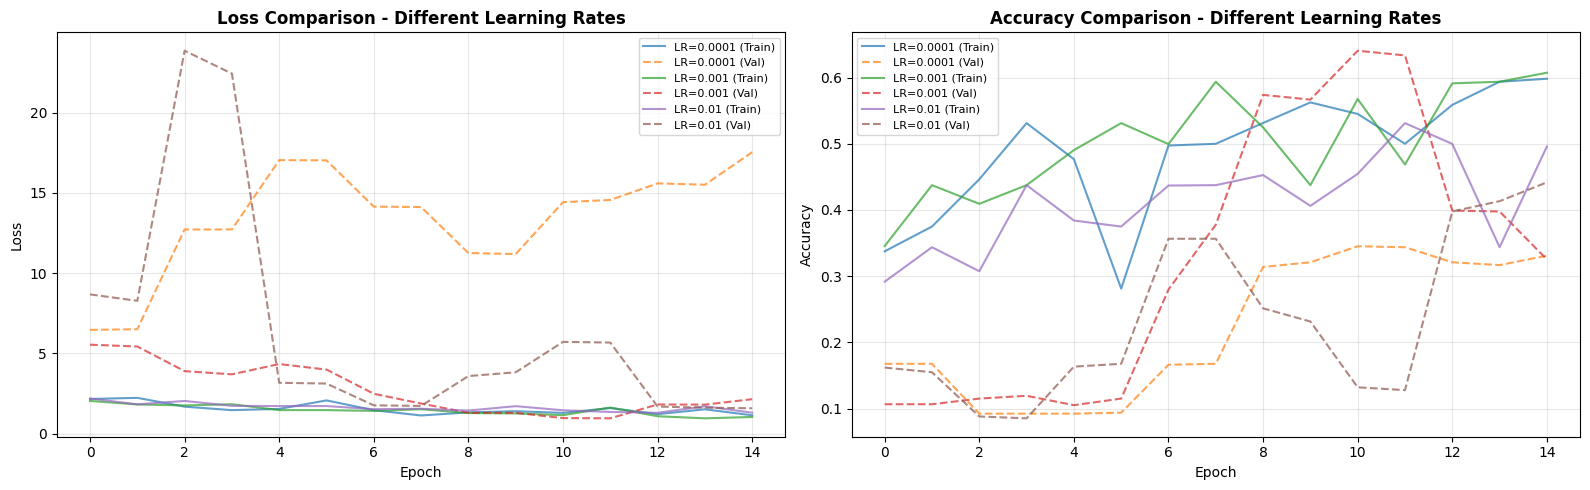

In [14]:
# Plot learning rate comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics = ['loss', 'accuracy']
titles = ['Loss Comparison - Different Learning Rates', 'Accuracy Comparison - Different Learning Rates']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    for lr in learning_rates:
        # Training curves
        axes[idx].plot(lr_histories[lr].history[metric],
                      label=f'LR={lr} (Train)', alpha=0.7)
        # Validation curves
        axes[idx].plot(lr_histories[lr].history[f'val_{metric}'],
                      label=f'LR={lr} (Val)', linestyle='--', alpha=0.7)

    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel(metric.capitalize())
    axes[idx].legend(fontsize=8, loc='best')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Train Custom CNN with Best Learning Rate

In [15]:
tf.keras.backend.clear_session()
model_cnn = build_cnn()

selected_lr = 0.001

model_cnn.compile(optimizer=Adam(learning_rate=selected_lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

print(f"Training with LR={selected_lr}, Batch={BATCH_SIZE}")
print("="*60)

train_generator.reset()
val_generator.reset()

history_cnn = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

plt.close('all')
gc.collect()

print(f"\nTraining completed at epoch {len(history_cnn.history['loss'])}")
print(f"Best val accuracy: {max(history_cnn.history['val_accuracy']):.4f}")

Training with LR=0.001, Batch=32
Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 73s 584ms/step - accuracy: 0.3019 - loss: 2.1139 - val_accuracy: 0.1051 - val_loss: 32.3905 - learning_rate: 0.0010
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5000 - loss: 1.5476 - val_accuracy: 0.1051 - val_loss: 32.5333 - learning_rate: 0.0010
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 51s 492ms/step - accuracy: 0.3940 - loss: 1.8533 - val_accuracy: 0.0980 - val_loss: 4.6676 - learning_rate: 0.0010
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3438 - loss: 2.0109 - val_accuracy: 0.0952 - val_loss: 4.4585 - learning_rate: 0.0010
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 51s 495ms/step - accuracy: 0.4724 - loss: 1.4952 - val_accuracy: 0.1023 - val_loss: 5.6174 - learning_rate: 0.0010
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3438 - loss: 1.4677 - val_accuracy: 0.1023 - val_loss: 5.3922 - learning_rate: 0.0010
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 5

In [18]:
# Save the trained Custom CNN model
model_cnn.save('custom_cnn_model.h5')
print("✓ Custom CNN model saved as 'custom_cnn_model.h5'")

✓ Custom CNN model saved as 'custom_cnn_model.h5'


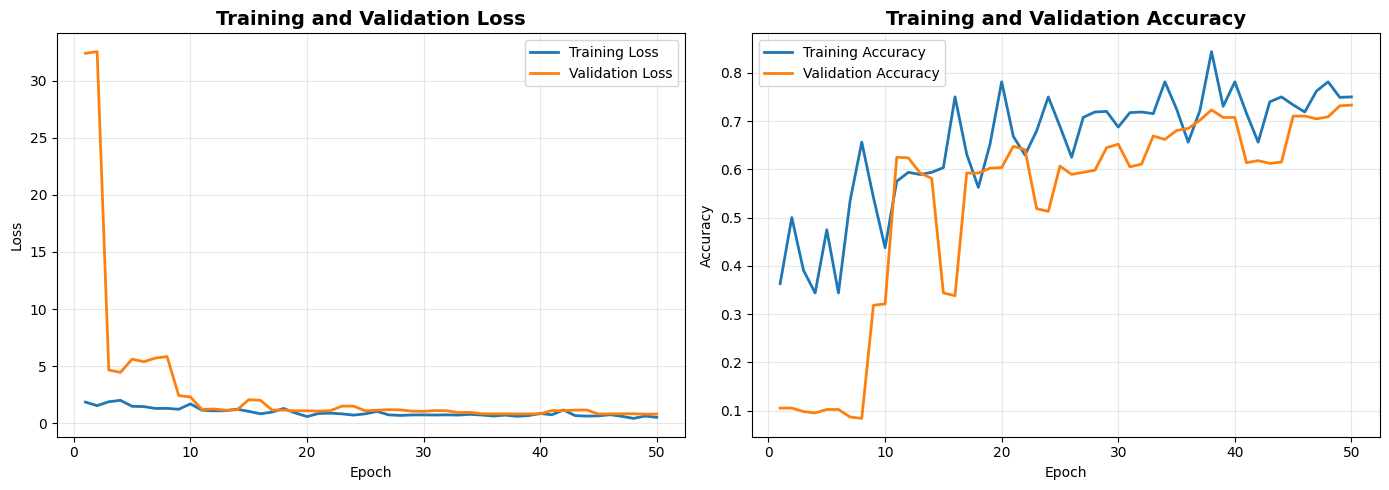

In [16]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract history data
history_data = {
    'Loss': (history_cnn.history['loss'], history_cnn.history['val_loss']),
    'Accuracy': (history_cnn.history['accuracy'], history_cnn.history['val_accuracy'])
}

# Plot each metric
for idx, (metric, (train_data, val_data)) in enumerate(history_data.items()):
    epochs = range(1, len(train_data) + 1)
    axes[idx].plot(epochs, train_data, label=f'Training {metric}', linewidth=2)
    axes[idx].plot(epochs, val_data, label=f'Validation {metric}', linewidth=2)
    axes[idx].set_title(f'Training and Validation {metric}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel(metric)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Optimizer Comparison (Adam vs SGD vs SGD+Momentum)

In [42]:
from tensorflow.keras.optimizers import SGD, Adam

optimizers = {
    'Adam': Adam(learning_rate=0.001),
    'SGD': SGD(learning_rate=0.01),
    'SGD+Momentum': SGD(learning_rate=0.01, momentum=0.9)
}

results = {}
histories = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name} optimizer...")

    # Clear previous session to avoid clutter
    tf.keras.backend.clear_session()
    plt.close('all')
    gc.collect()

    # Rebuild and compile the CNN
    model = build_cnn()
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Reset generators
    train_generator.reset()
    val_generator.reset()
    test_generator.reset()

    # Train the model
    h = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Evaluate on test set
    loss, acc = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=0)
    results[name] = {'Test Accuracy': acc, 'Test Loss': loss}
    histories[name] = h

    print(f"  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Test Loss: {loss:.4f}")

    # Cleanup to avoid memory issues
    plt.close('all')
    gc.collect()

# Display results in table
print("\nOPTIMIZER COMPARISON RESULTS:")
pd.DataFrame(results).T



Training with Adam optimizer...
Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 72s 572ms/step - accuracy: 0.2976 - loss: 2.2301 - val_accuracy: 0.1676 - val_loss: 9.9304
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3438 - loss: 1.6231 - val_accuracy: 0.1676 - val_loss: 9.1911
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 51s 493ms/step - accuracy: 0.4053 - loss: 1.8546 - val_accuracy: 0.1562 - val_loss: 2.7582
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4375 - loss: 1.5903 - val_accuracy: 0.1335 - val_loss: 2.7122
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 82s 796ms/step - accuracy: 0.4911 - loss: 1.4936 - val_accuracy: 0.2003 - val_loss: 3.0020
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4062 - loss: 1.3869 - val_accuracy: 0.1989 - val_loss: 3.0845
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 51s 489ms/step - accuracy: 0.5595 - loss: 1.2610 - val_accuracy: 0.2472 - val_loss: 2.7122
Epoch 8/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - a

,Test Accuracy,Test Loss
Adam,0.480114,1.702578
SGD,0.117898,39.130943
SGD+Momentum,0.514205,1.389097


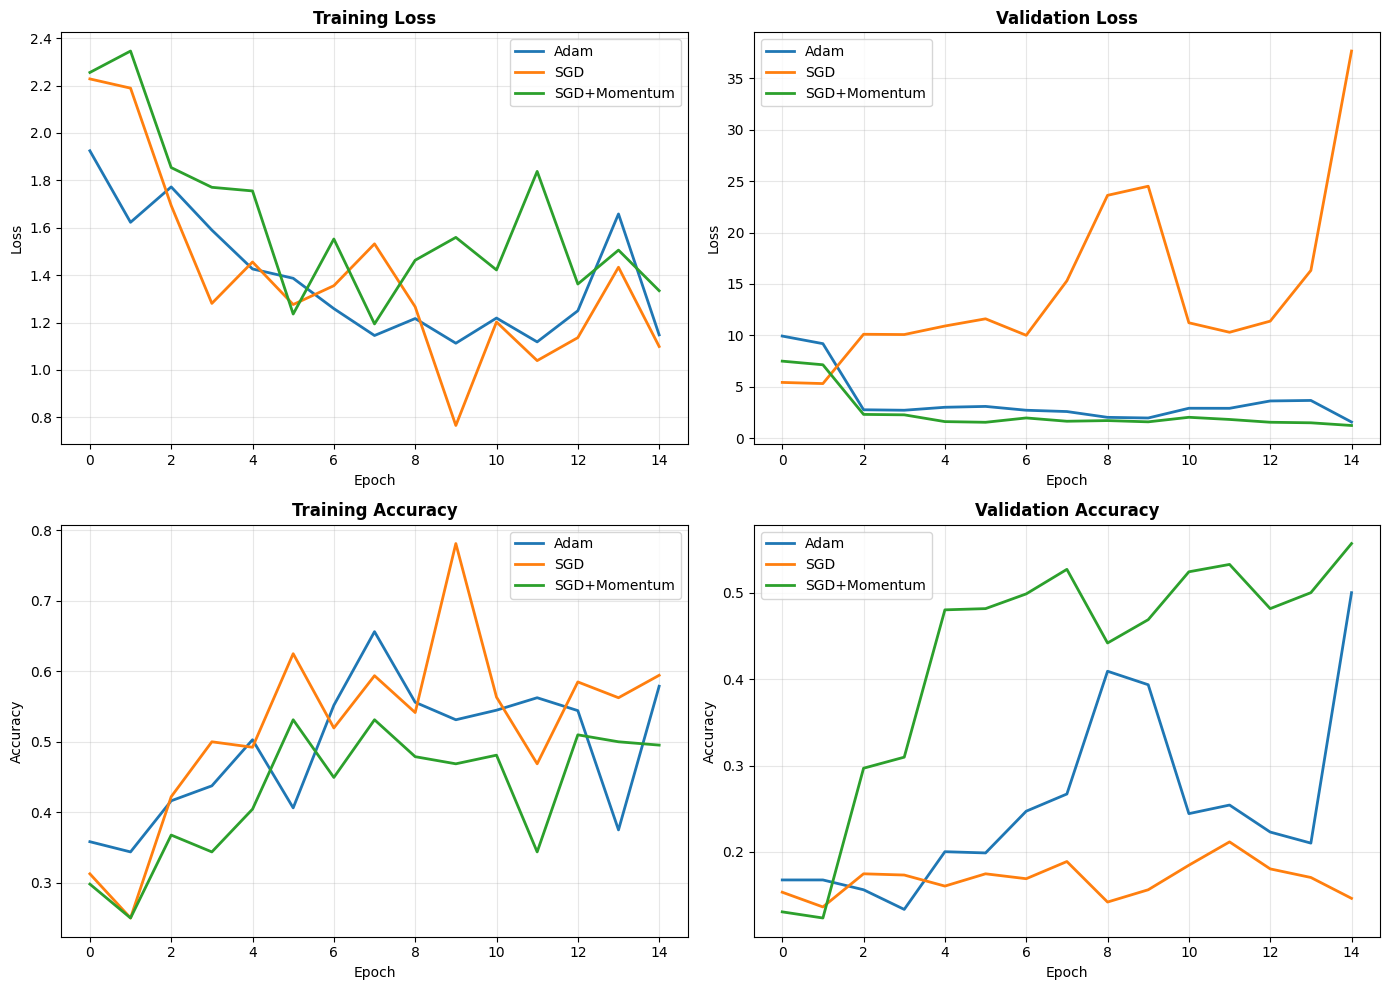

In [43]:
# Plot optimizer comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot configurations
plot_configs = [
    ('loss', 'Training Loss', (0, 0)),
    ('val_loss', 'Validation Loss', (0, 1)),
    ('accuracy', 'Training Accuracy', (1, 0)),
    ('val_accuracy', 'Validation Accuracy', (1, 1))
]

for metric, title, (row, col) in plot_configs:
    for name, history in histories.items():
        axes[row, col].plot(history.history[metric], label=name, linewidth=2)

    axes[row, col].set_title(title, fontweight='bold')
    axes[row, col].set_xlabel('Epoch')
    axes[row, col].set_ylabel(metric.split('_')[-1].capitalize())
    axes[row, col].legend()
    axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate Custom CNN

In [20]:
test_generator.reset()
loss, acc = model_cnn.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=0)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 0.7145 (71.45%)
Test Loss: 0.8587


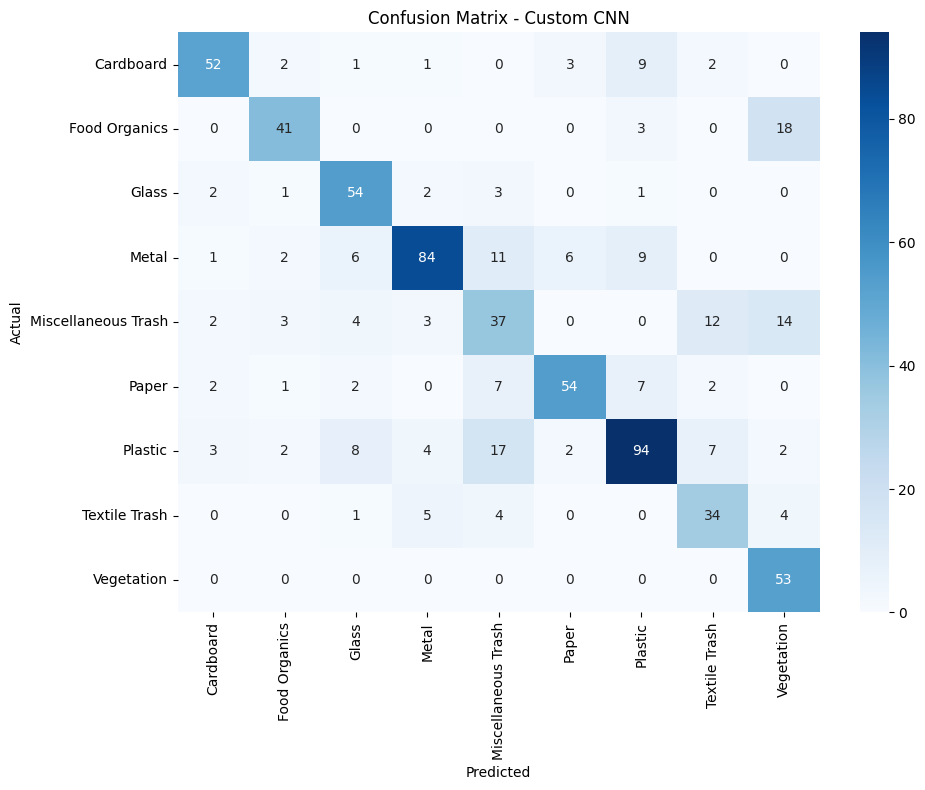

In [21]:
# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Generate predictions
test_generator.reset()
y_pred_proba = model_cnn.predict(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes[:len(y_pred)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Custom CNN')
plt.tight_layout()
plt.show()

In [22]:
# Classification report
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

                     precision    recall  f1-score   support

          Cardboard     0.8387    0.7429    0.7879        70
      Food Organics     0.7885    0.6613    0.7193        62
              Glass     0.7105    0.8571    0.7770        63
              Metal     0.8485    0.7059    0.7706       119
Miscellaneous Trash     0.4684    0.4933    0.4805        75
              Paper     0.8308    0.7200    0.7714        75
            Plastic     0.7642    0.6763    0.7176       139
      Textile Trash     0.5965    0.7083    0.6476        48
         Vegetation     0.5824    1.0000    0.7361        53

           accuracy                         0.7145       704
          macro avg     0.7143    0.7295    0.7120       704
       weighted avg     0.7336    0.7145    0.7161       704



## 10. Transfer Learning - MobileNetV2 (Pre-trained Model)

In [23]:
# Import transfer learning components
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2

tf.keras.backend.clear_session()
plt.close('all')
gc.collect()

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(num_classes, activation='softmax', dtype='float32')(x)

model_mobilenet = Model(inputs=base.input, outputs=out)
model_mobilenet.compile(optimizer=Adam(learning_rate=0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

print(f"✓ MobileNetV2: {model_mobilenet.count_params():,} params")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ MobileNetV2: 2,588,233 params


In [24]:
train_generator.reset()
val_generator.reset()

history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict
)

plt.close('all')
gc.collect()

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 79s 607ms/step - accuracy: 0.3998 - loss: 1.6869 - val_accuracy: 0.6321 - val_loss: 0.9187
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7188 - loss: 0.6644 - val_accuracy: 0.6378 - val_loss: 0.9288
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 46s 447ms/step - accuracy: 0.6473 - loss: 0.9215 - val_accuracy: 0.6932 - val_loss: 0.8367
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7500 - loss: 0.7064 - val_accuracy: 0.7031 - val_loss: 0.8395
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 45s 441ms/step - accuracy: 0.7143 - loss: 0.7605 - val_accuracy: 0.7330 - val_loss: 0.7189
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7188 - loss: 0.6495 - val_accuracy: 0.7315 - val_loss: 0.7318
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 47s 454ms/step - accuracy: 0.7318 - loss: 0.6941 - val_accuracy: 0.7457 - val_loss: 0.6836
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7812 - loss: 0.7911 - 

791

In [25]:
# Save MobileNetV2 model
model_mobilenet.save('mobilenet_v2_model.h5')
print("✓ MobileNetV2 model saved as 'mobilenet_v2_model.h5'")

✓ MobileNetV2 model saved as 'mobilenet_v2_model.h5'


## 11. Transfer Learning - VGG16 (Pre-trained Model)

In [32]:
# Import VGG16
from tensorflow.keras.applications import VGG16

tf.keras.backend.clear_session()
plt.close('all')
gc.collect()

base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(num_classes, activation='softmax', dtype='float32')(x)

model_vgg = Model(inputs=base.input, outputs=out)
model_vgg.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print(f"✓ VGG16: {model_vgg.count_params():,} params")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ VGG16: 14,848,329 params


In [33]:
train_generator.reset()
val_generator.reset()

# Callbacks for VGG16
vgg_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

history_vgg = model_vgg.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight_dict,
    callbacks=vgg_callbacks
)

plt.close('all')
gc.collect()

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 628ms/step - accuracy: 0.2213 - loss: 2.1159 - val_accuracy: 0.4489 - val_loss: 1.6038 - learning_rate: 0.0010
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5312 - loss: 1.5758 - val_accuracy: 0.4361 - val_loss: 1.6041 - learning_rate: 0.0010
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 53s 512ms/step - accuracy: 0.4000 - loss: 1.5470 - val_accuracy: 0.5085 - val_loss: 1.3909 - learning_rate: 0.0010
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3750 - loss: 1.5337 - val_accuracy: 0.5071 - val_loss: 1.3889 - learning_rate: 0.0010
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 53s 513ms/step - accuracy: 0.4715 - loss: 1.3896 - val_accuracy: 0.6009 - val_loss: 1.2636 - learning_rate: 0.0010
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3750 - loss: 1.6830 - val_accuracy: 0.5909 - val_loss: 1.2676 - learning_rate: 0.0010
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 53s 514ms/step - accuracy: 0.4958 - 

1716

In [34]:
# Save VGG16 model
model_vgg.save('vgg16_model.h5')
print("✓ VGG16 model saved as 'vgg16_model.h5'")

✓ VGG16 model saved as 'vgg16_model.h5'


## 12. Compare Transfer Learning Models

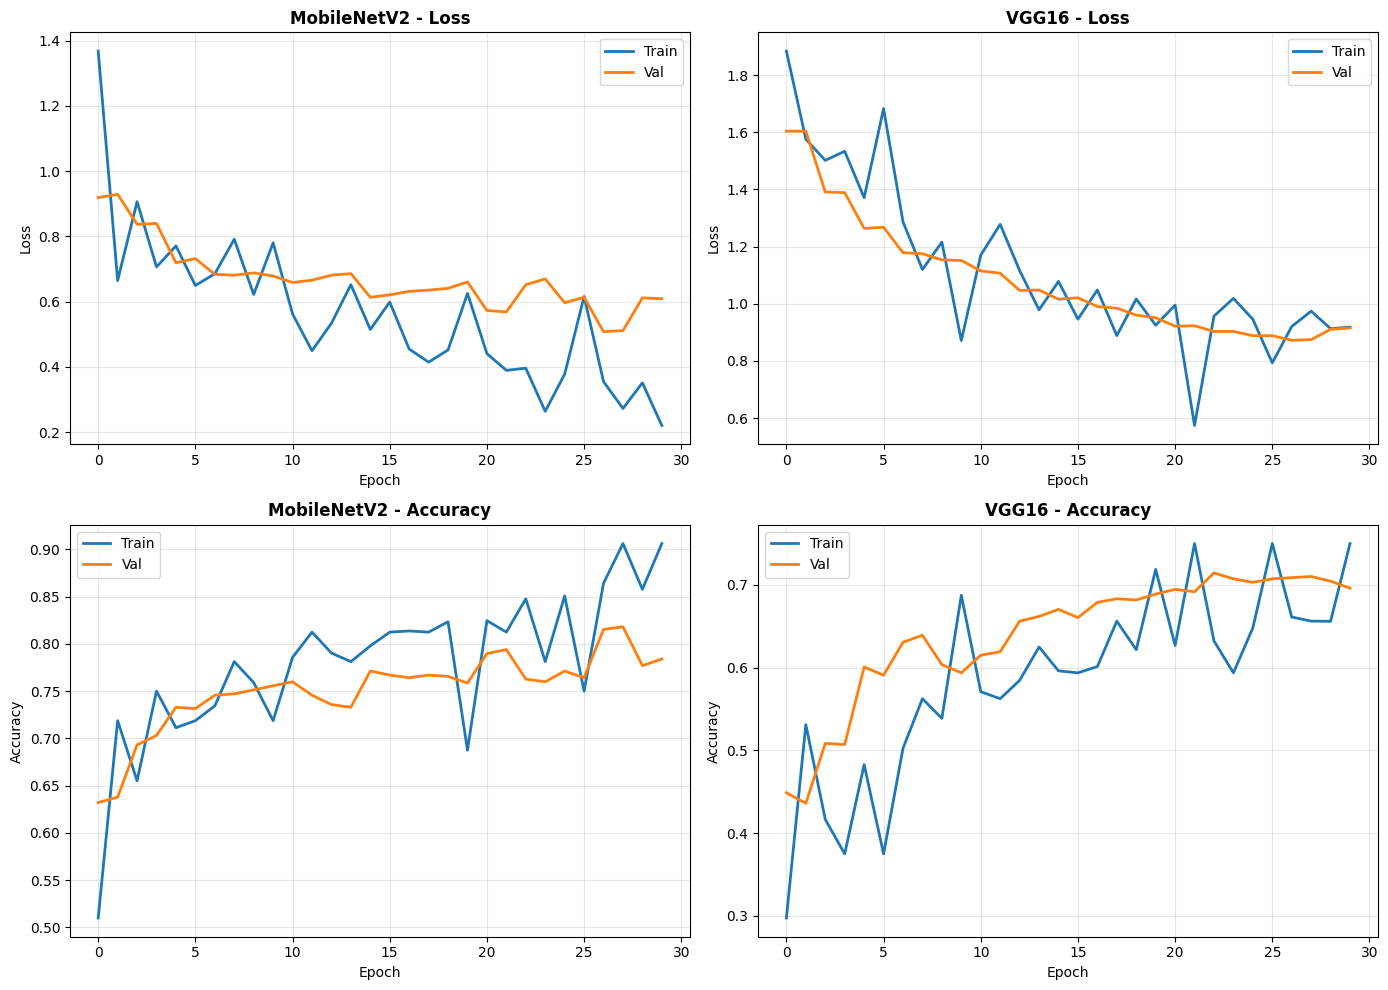

In [35]:
# Compare transfer learning training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model histories
model_histories = [
    ('MobileNetV2', history_mobilenet),
    ('VGG16', history_vgg)
]

# Metrics to plot
metrics = ['loss', 'accuracy']

for col, (model_name, history) in enumerate(model_histories):
    for row, metric in enumerate(metrics):
        ax = axes[row, col]
        ax.plot(history.history[metric], label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val', linewidth=2)
        ax.set_title(f'{model_name} - {metric.capitalize()}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close('all')

In [36]:
# Evaluate transfer learning models
test_generator.reset()
loss_m, acc_m = model_mobilenet.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=0)

test_generator.reset()
loss_v, acc_v = model_vgg.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=0)

print(f"MobileNetV2     - Acc: {acc_m:.4f} ({acc_m*100:.2f}%)")
print(f"VGG16           - Acc: {acc_v:.4f} ({acc_v*100:.2f}%)")

MobileNetV2     - Acc: 0.7656 (76.56%)
VGG16           - Acc: 0.6847 (68.47%)


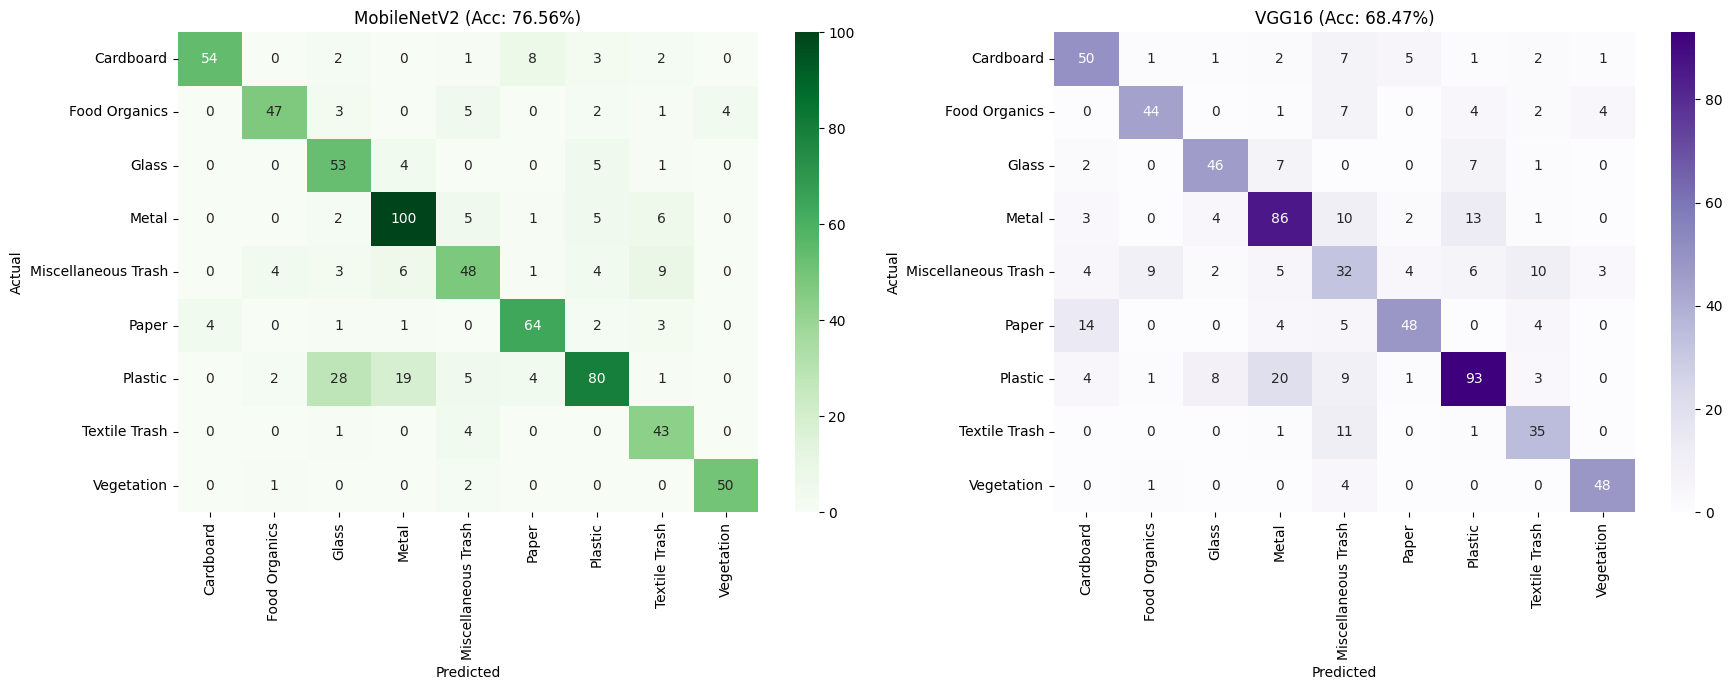

In [37]:
# Confusion matrices for transfer learning models
test_generator.reset()
y_pred_proba_m = model_mobilenet.predict(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=0)
y_pred_m = np.argmax(y_pred_proba_m, axis=1)
y_true_m = test_generator.classes[:len(y_pred_m)]

test_generator.reset()
y_pred_proba_v = model_vgg.predict(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=0)
y_pred_v = np.argmax(y_pred_proba_v, axis=1)
y_true_v = test_generator.classes[:len(y_pred_v)]

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
class_names = list(test_generator.class_indices.keys())

sns.heatmap(confusion_matrix(y_true_m, y_pred_m), annot=True, fmt='d',
            cmap='Greens', ax=ax[0], xticklabels=class_names, yticklabels=class_names)
ax[0].set_title(f'MobileNetV2 (Acc: {acc_m:.2%})')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_true_v, y_pred_v), annot=True, fmt='d',
            cmap='Purples', ax=ax[1], xticklabels=class_names, yticklabels=class_names)
ax[1].set_title(f'VGG16 (Acc: {acc_v:.2%})')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
plt.close('all')

In [38]:
# Classification reports
class_names = list(test_generator.class_indices.keys())

print("MobileNetV2:")
print(classification_report(y_true_m, y_pred_m, target_names=class_names, digits=4))

print("\nVGG16:")
print(classification_report(y_true_v, y_pred_v, target_names=class_names, digits=4))

MobileNetV2:
                     precision    recall  f1-score   support

          Cardboard     0.9310    0.7714    0.8438        70
      Food Organics     0.8704    0.7581    0.8103        62
              Glass     0.5699    0.8413    0.6795        63
              Metal     0.7692    0.8403    0.8032       119
Miscellaneous Trash     0.6857    0.6400    0.6621        75
              Paper     0.8205    0.8533    0.8366        75
            Plastic     0.7921    0.5755    0.6667       139
      Textile Trash     0.6515    0.8958    0.7544        48
         Vegetation     0.9259    0.9434    0.9346        53

           accuracy                         0.7656       704
          macro avg     0.7796    0.7910    0.7768       704
       weighted avg     0.7812    0.7656    0.7649       704


VGG16:
                     precision    recall  f1-score   support

          Cardboard     0.6494    0.7143    0.6803        70
      Food Organics     0.7857    0.7097    0.7458        62

## 13. Final Model Comparison (Custom CNN vs Transfer Learning)

In [39]:
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'MobileNetV2', 'VGG16'],
    'Accuracy': [acc, acc_m, acc_v],
    'Loss': [loss, loss_m, loss_v],
    'Parameters (M)': [
        model_cnn.count_params() / 1e6,
        model_mobilenet.count_params() / 1e6,
        model_vgg.count_params() / 1e6
    ]
}).sort_values('Accuracy', ascending=False)

print(comparison.to_string(index=False))

      Model  Accuracy     Loss  Parameters (M)
MobileNetV2  0.765625 0.677716        2.588233
 Custom CNN  0.714489 0.858705       13.433641
      VGG16  0.684659 0.900313       14.848329


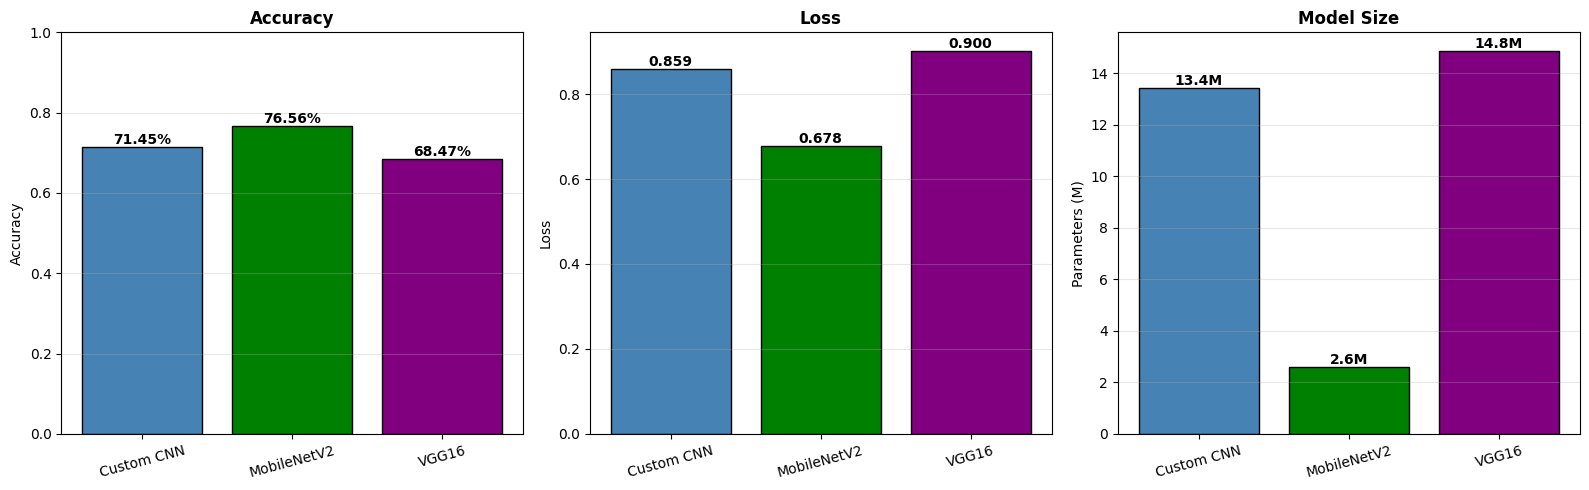

In [40]:
# Model comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Data preparation
model_names = ['Custom CNN', 'MobileNetV2', 'VGG16']
metrics = {
    'Accuracy': [acc, acc_m, acc_v],
    'Loss': [loss, loss_m, loss_v],
    'Parameters (M)': [m.count_params() / 1e6 for m in [model_cnn, model_mobilenet, model_vgg]]
}
colors = ['steelblue', 'green', 'purple']

# Plot configurations
plot_configs = [
    {'title': 'Accuracy', 'ylabel': 'Accuracy', 'ylim': (0, 1), 'format': '.2%'},
    {'title': 'Loss', 'ylabel': 'Loss', 'ylim': None, 'format': '.3f'},
    {'title': 'Model Size', 'ylabel': 'Parameters (M)', 'ylim': None, 'format': '.1f', 'suffix': 'M'}
]

# Create plots
for idx, (ax, config) in enumerate(zip(axes, plot_configs)):
    metric_key = list(metrics.keys())[idx]
    bars = ax.bar(model_names, metrics[metric_key], color=colors, edgecolor='black')

    ax.set_ylabel(config['ylabel'])
    ax.set_title(config['title'], fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

    if config['ylim']:
        ax.set_ylim(config['ylim'])

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        suffix = config.get('suffix', '')
        label = f"{height:{config['format']}}{suffix}"
        ax.text(bar.get_x() + bar.get_width()/2., height, label,
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()
plt.close('all')

## 14. Model Saving & Loading

All trained models have been saved for future use

In [41]:
# Summary of saved models
saved_models = {
    'Custom CNN': 'custom_cnn_model.h5',
    'MobileNetV2': 'mobilenet_v2_model.h5',
    'VGG16': 'vgg16_model.h5'
}

print("Saved Models:")
print("="*60)
for model_name, filename in saved_models.items():
    print(f"  {model_name:20s} → {filename}")
print("="*60)

# To load a model later, use:
# loaded_model = tf.keras.models.load_model('custom_cnn_model.h5')

Saved Models:
  Custom CNN           → custom_cnn_model.h5
  MobileNetV2          → mobilenet_v2_model.h5
  VGG16                → vgg16_model.h5


---
**Dataset Citation:**  
Single, S., Iranmanesh, S., & Raad, R. (2023). RealWaste [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5SS4G